# Pandas 3 - Advanced Pandas

> **MLCourse · Data Science Foundations · 02_pandas**

This is the power-user notebook: time series, MultiIndex tables, production-grade
string handling, method chaining, and the memory/copy subtleties that separate
beginners from professionals.

### What you'll learn
- Working with dates: `to_datetime`, `.dt` accessors, `resample`, rolling windows
- Lag features, `% change`, and shift-based feature engineering
- MultiIndex DataFrames: building, slicing with `xs`, stacking/unstacking
- Ordered categorical columns (and why they save memory)
- The full `.str` string-methods suite including regex extraction
- Method chaining style + `assign` / `pipe`
- `where` / `mask`, `nlargest` / `nsmallest`
- The infamous `SettingWithCopyWarning` - what causes it, how to fix it
- Memory optimization and DataFrame styling

### Standard imports for this notebook


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

np.random.seed(42)          # reproducibility for any random data we build
sns.set_theme()             # nicer plot defaults

print("pandas version:", pd.__version__)


### 1. Time Series - dates done right

Real-world data arrives with timestamps. Pandas treats a column of datetimes as a
*first-class index*, unlocking label-based date slicing, aggregation by period,
and window statistics.

### 1.1 Parsing strings to datetimes


### Raw data usually stores dates as STRINGS - useless for math until parsed.


In [ ]:
raw_dates = pd.Series(["2024-01-15", "2024-02-20", "2024/03/05", "not-a-date", None])

# errors="coerce" turns unparseable values into NaT (Not a Time) instead of crashing.
# That failure count is itself diagnostic information about your data quality!
parsed = pd.to_datetime(raw_dates, format="mixed", errors="coerce")

comparison = pd.DataFrame({"raw": raw_dates, "parsed": parsed})
print(comparison)

print("\nCoerced (failed) values:", parsed.isna().sum())


> ⚠️ **Common pitfall:** without `format=`, pandas guesses. It's convenient but slow
on large files and occasionally wrong (`03/05/2024` - March 5th or May 3rd?).
For known formats always pass an explicit one:

```python
pd.to_datetime(s, format="%d/%m/%Y")   # day-first, unambiguous
```

### Generating regular date ranges - useful for synthetic series and reindexing.


In [ ]:
daily = pd.date_range(start="2024-01-01", periods=8, freq="D")     # 8 consecutive days
weekly = pd.date_range("2024-01-01", "2024-03-01", freq="W")       # every week end

print(daily[:4])
print("\nFrequency aliases you'll use constantly:")
for alias, meaning in [("D", "calendar day"), ("B", "business day"), ("W", "weekly"),
                       ("MS", "month start"), ("QE", "quarter end"), ("YE", "year end")]:
    print(f"  {alias:>3} -> {meaning}")


### 1.2 A datetime index unlocks date superpowers


### Build a small daily sales series indexed by date.


In [ ]:
dates = pd.date_range("2022-01-01", "2023-12-31", freq="D")
sales = pd.Series(
    1000
    + np.arange(len(dates)) * 0.5                      # gentle upward trend
    + 120 * np.sin(2 * np.pi * dates.dayofyear / 365)  # annual seasonality wave
    + np.random.normal(0, 40, len(dates)),             # noise
    index=dates,
    name="sales",
).round(2)

sales.head(3)


### PARTIAL STRING INDEXING - no more dt.datetime gymnastics.


In [ ]:
# Selecting everything from one year:
print("2022 total sales:", sales.loc["2022"].sum().round(0))

# A single month:
print("Jan 2023 mean    :", round(sales.loc["2023-01"].mean(), 1))

# A range of dates (label slices are INCLUSIVE):
q1_2023 = sales.loc["2023-01-01":"2023-03-31"]
print("Q1 2023 days     :", len(q1_2023))


### 1.3 The `.dt` accessor - components of every timestamp


In [6]:
df_ts = sales.reset_index().rename(columns={"index": "date", "sales": "sales"})

# .dt gives every date part as vectorized columns - no Python loops needed.
df_ts["year"]       = df_ts["date"].dt.year
df_ts["month"]      = df_ts["date"].dt.month
df_ts["day"]        = df_ts["date"].dt.day
df_ts["dayofweek"]  = df_ts["date"].dt.dayofweek          # Mon=0 ... Sun=6
df_ts["month_name"] = df_ts["date"].dt.month_name()
df_ts["is_weekend"] = df_ts["date"].dt.dayofweek >= 5

df_ts.sample(5, random_state=42)

,date,sales,year,month,day,dayofweek,month_name,is_weekend
468,2023-04-14,1329.90,2023,4,14,4,April,False
148,2022-05-29,1160.31,2022,5,29,6,May,True
302,2022-10-30,1075.78,2022,10,30,6,October,True
355,2022-12-22,1118.88,2022,12,22,3,December,False
515,2023-05-31,1349.64,2023,5,31,2,May,False


> 💡 **Pro tip:** `.dt` also exposes business logic like `is_month_end`,
`quarter`, and `days_in_month`. Tab-complete on `df_ts["date"].dt.` to explore.
These extracted features are the bread and butter of time-series ML models.

### 1.4 Resampling - groupby for time

`resample()` is `groupby` where the groups are time buckets. Downsampling
(daily→monthly) needs an aggregation; upsampling needs a fill strategy.

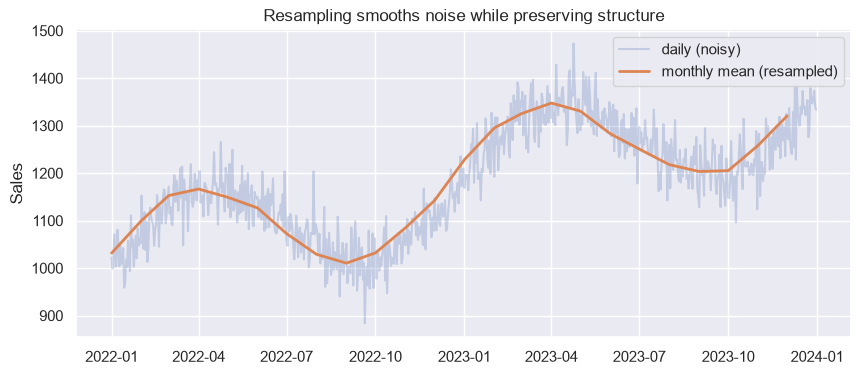

Quarterly sums:
2022-03-31     98528.0
2022-06-30    104424.0
2022-09-30     95465.0
2022-12-31     99944.0
2023-03-31    115422.0
Freq: QE-DEC, Name: sales, dtype: float64


In [7]:
monthly = sales.resample("MS").mean()   # MS = month start bucket; stable alias in every pandas version
quarterly = sales.resample("QE").sum()  # QE = quarter end

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sales.index, sales.values, alpha=0.25, label="daily (noisy)")
ax.plot(monthly.index, monthly.values, lw=2, label="monthly mean (resampled)")
ax.set_title("Resampling smooths noise while preserving structure")
ax.set_ylabel("Sales")
ax.legend()
plt.show()

print("Quarterly sums:")
print(quarterly.round(0).head())

### 1.5 Rolling & expanding windows


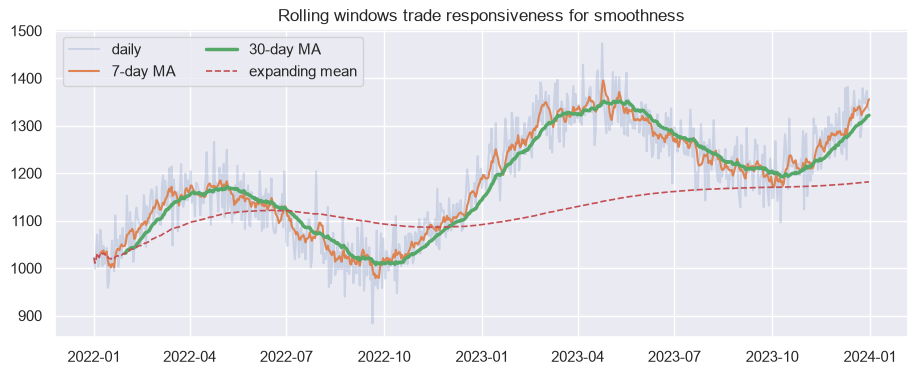

In [8]:
# rolling(window).mean() answers: "what does the trend look like if I average
# over the last N observations?" - the classic smoothing tool.
roll7  = sales.rolling(window=7).mean()      # weekly moving average
roll30 = sales.rolling(window=30).mean()     # monthly moving average

# expanding() uses ALL history up to each point - cumulative view.
expanding_mean = sales.expanding().mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sales, alpha=0.2, label="daily")
ax.plot(roll7, lw=1.5, label="7-day MA")
ax.plot(roll30, lw=2.5, label="30-day MA")
ax.plot(expanding_mean, ls="--", lw=1.2, label="expanding mean")
ax.set_title("Rolling windows trade responsiveness for smoothness")
ax.legend(ncols=2)
plt.show()

> ⚠️ **Common pitfall:** the first `window-1` values of a rolling result are NaN
(there isn't enough history yet). Either accept them or pass `min_periods=1`.

### 1.6 Shift & pct_change - lag features in one line


In [9]:
small = sales.loc["2023-01":"2023-01-07"]

feat = pd.DataFrame({
    "sales": small,                          # today
    "yesterday": small.shift(1),             # yesterday  (lag-1 feature)
    "day_over_day": small.pct_change(),      # % change vs yesterday
    "delta": small.diff(),                   # absolute change vs yesterday
}).round(2)

feat

,sales,yesterday,day_over_day,delta
2023-01-01,1168.52,NaN,NaN,NaN
2023-01-02,1196.09,1168.52,0.02,27.57
2023-01-03,1190.20,1196.09,-0.00,-5.89
2023-01-04,1196.16,1190.20,0.01,5.96
2023-01-05,1163.90,1196.16,-0.03,-32.26
2023-01-06,1198.35,1163.90,0.03,34.45
2023-01-07,1219.84,1198.35,0.02,21.49


> 💡 **Pro tip:** lag features (`shift`) are how you convert a forecasting problem
into supervised learning: predict *today* from *yesterday*, *last week*
(`shift(7)`), *same month last year* (`shift(365)`)…

### 1.7 Worked mini-analysis: the flights dataset


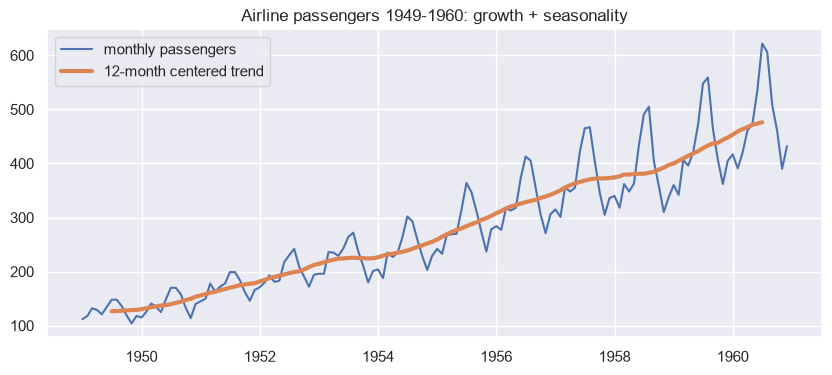

YoY growth (last year shown):
date
1959-01-01    20.0
1959-02-01    24.0
1959-03-01    44.0
Name: passengers, dtype: float64


In [10]:
try:
    flights = sns.load_dataset("flights")
except Exception as e:
    print("Offline? Build fallback frame.", e)
    flights = pd.DataFrame()

if not flights.empty:
    # flights is LONG format: year | month | passengers (one row per month).
    # Construct a real datetime from parts - a pattern you will reuse forever.
    flights["date"] = pd.to_datetime(
        flights["year"].astype(str) + "-" + flights["month"].astype(str) + "-01"
    )
    fts = flights.set_index("date")["passengers"].sort_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(fts, label="monthly passengers")
    ax.plot(fts.rolling(12, center=True).mean(), lw=3, label="12-month centered trend")
    ax.set_title("Airline passengers 1949-1960: growth + seasonality")
    ax.legend()
    plt.show()

    # Year-over-year growth in two lines thanks to shift on a monthly series:
    yoy = fts.diff(12)                     # same month, previous year
    print("YoY growth (last year shown):")
    print(yoy.loc["1959"].head(3))

### 2. MultiIndex - tables within tables

A MultiIndex lets one axis carry several levels of labels - think
*"region → city"* rows or *"metric → quarter"* columns. Groupby with multiple keys
produces them naturally.

### Small HR-style dataset


In [ ]:
hr = pd.DataFrame({
    "region":  ["East", "East", "West", "West", "East", "West"],
    "dept":    ["Sales", "Eng", "Sales", "Eng", "Eng", "Sales"],
    "quarter": ["Q1", "Q1", "Q1", "Q1", "Q2", "Q2"],
    "revenue": [220, 340, 190, 410, 260, 205],
})

# Grouping by TWO keys returns a Series with a 2-level row index.
multi = hr.groupby(["region", "dept"])["revenue"].sum()
print(multi)
print("\nIndex names:", multi.index.names)


### Selecting from a MultiIndex:


In [ ]:
# All levels except the last stay fixed -> .loc[(outer, inner)]
print("East/Sales revenue :", multi.loc[("East", "Sales")])

# Slice just the outer level -> every dept within East
print("\nAll East rows:\n", multi.loc["East"])

# xs(): cross-section - take a slice at a DEEPER level while keeping the shape.
print("\nxs('Sales', level='dept'):\n", multi.xs("Sales", level="dept"))


### 2.1 stack / unstack - reshaping between long and wide


In [13]:
wide = multi.unstack()        # innermost row level -> columns
print("unstack() -> wide:\n", wide)

back = wide.stack()           # and back again
print("\nstack() -> long (identical):\n", back.head(4))

unstack() -> wide:
 dept    Eng  Sales
region            
East    600    220
West    410    395

stack() -> long (identical):
 region  dept 
East    Eng      600
        Sales    220
West    Eng      410
        Sales    395
dtype: int64


> 💡 **Pro tip:** `unstack` is the fastest route from a grouped summary to a
heatmap-ready matrix: `multi.unstack()` then feed it straight into
`sns.heatmap(...)`.

### 3. Ordered categoricals - categories that sort properly


In [14]:
sizes = pd.Series(["M", "S", "L", "XL", "M", "S", "L"])

# Plain object dtype sorts ALPHABETICALLY - semantically wrong for sizes!
print("object sort (wrong):", sorted(sizes.unique()))

# Declare category order ONCE and every sort/groupby respects it forever.
ordered_sizes = pd.Categorical(
    sizes,
    categories=["S", "M", "L", "XL"],   # the TRUE order
    ordered=True,
)
size_series = pd.Series(ordered_sizes, name="size")

print("\ncategory sort (right):", list(size_series.sort_values().unique()))

# Comparisons become meaningful:
mask = size_series >= "L"
print("\nSizes >= L:", mask.tolist())

object sort (wrong): ['L', 'M', 'S', 'XL']

category sort (right): ['S', 'M', 'L', 'XL']

Sizes >= L: [False, False, True, True, False, False, True]


### Memory win - object dtype stores a Python string per cell;


In [ ]:
# category dtype stores integers + one lookup table.
n = 500_000
big_object = pd.Series(np.random.choice(["low", "mid", "high"], n))
big_category = big_object.astype("category")

print(f"object   : {big_object.memory_usage(deep=True)/1e6:.1f} MB")
print(f"category : {big_category.memory_usage(deep=True)/1e6:.1f} MB")

# Renaming categories updates every value at once:
renamed = size_series.cat.rename_categories({"S": "Small", "M": "Medium", "L": "Large", "XL": "Extra Large"})
print("\nRenamed:", renamed.unique().tolist())


### 4. The `.str` suite - vectorized text surgery

Every string operation becomes an array operation via `.str`. Combined with regex
it replaces most manual text munging loops.

In [16]:
people = pd.DataFrame({
    "email": ["Ana.Silva@Gmail.com ", " bob@test.org", "CARLA@mail.io", "dan@TEST.org "],
    "full_name": ["Silva, Ana", "Jones, Bob", "Lopez, Carla", "Nash, Dan"],
    "phone": ["555-0101", "555.0202", "555 0303", "5550404"],
})

people["email_clean"] = people["email"].str.strip().str.lower()          # trim + case
people["username"]    = people["email_clean"].str.split("@").str[0]      # split + index
people["domain"]      = people["email_clean"].str.extract(r"@(\w+)\.")   # regex capture
people["first_name"]  = people["full_name"].str.extract(r",\s*(?P<first>\w+)")["first"]
people["digits"]      = people["phone"].str.replace(r"\D", "", regex=True)  # strip non-digits

people

,email,full_name,phone,email_clean,username,domain,first_name,digits
0,Ana.Silva@Gmail.com,"Silva, Ana",555-0101,ana.silva@gmail.com,ana.silva,gmail,Ana,5550101
1,bob@test.org,"Jones, Bob",555.0202,bob@test.org,bob,test,Bob,5550202
2,CARLA@mail.io,"Lopez, Carla",555 0303,carla@mail.io,carla,mail,Carla,5550303
3,dan@TEST.org,"Nash, Dan",5550404,dan@test.org,dan,test,Dan,5550404


> ⚠️ **Common pitfall:** `.str.contains("a.b")` treats "." as ANY character.
Escape literals: `\.`, or pass `regex=False` for plain substring search.

In [17]:
# str.get_dummies: turn a tag list into indicator columns - instant featurization!
tags = pd.DataFrame({"tags": ["python;pandas", "sql", "python;viz", "pandas;viz"]})
pd.concat([tags, tags["tags"].str.get_dummies(sep=";")], axis=1)

,tags,pandas,python,sql,viz
0,python;pandas,1,1,0,0
1,sql,0,0,1,0
2,python;viz,0,1,0,1
3,pandas;viz,1,0,0,1


### 5. Method chaining - readable pipelines

Professionals write transformations as one fluent pipeline instead of a swamp of
intermediate variables. `assign` adds columns, `query` filters, `pipe` injects
any custom function.

In [18]:
def add_tip_pct(df):                      # custom step for pipe()
    return df.assign(tip_pct=df["tip"] / df["total_bill"] * 100)

try:
    tips = sns.load_dataset("tips")
except Exception:
    tips = pd.DataFrame({"total_bill": [16.99], "tip": [1.01], "sex": ["Female"]})

result = (
    tips
    .query("total_bill < 40")                 # 1. filter
    .pipe(add_tip_pct)                        # 2. engineered column via function
    .groupby("day", observed=True)["tip_pct"] # 3. aggregate per day
    .mean()
    .round(2)
    .sort_values()
)
print(result)

day
Sat     15.36
Thur    16.27
Sun     17.03
Fri     17.28
Name: tip_pct, dtype: float64


> 💡 **Pro tip:** wrap the chain in parentheses (as above) and put one step per
line - that's the idiomatic pandas style you'll see in production codebases.

### 6. where / mask / nlargest - surgical selection


In [19]:
rng = np.random.default_rng(42)
scores = pd.Series(rng.normal(70, 15, 10).round(1), name="score")

keep_pass  = scores.where(scores >= 60)              # keep passing, NaN the rest
clamp_low  = scores.mask(scores < 60, other=60.0)    # replace failures with floor

compare = pd.DataFrame({"orig": scores, "where(>=60)": keep_pass, "masked floor": clamp_low})
print(compare)

# Top/bottom-k without sorting everything:
print("\nTop 3 scores:", scores.nlargest(3).tolist())
print("Bottom 3     :", scores.nsmallest(3).tolist())

# Top-n PER GROUP - a very common interview task:
top_tipper_per_day = (
    tips.sort_values("tip", ascending=False)
        .groupby("day", observed=True)
        .head(2)[["day", "sex", "tip"]]
)
print("\nTop 2 tippers per day:")
print(top_tipper_per_day)

   orig  where(>=60)  masked floor
0  74.6         74.6          74.6
1  54.4          NaN          60.0
2  81.3         81.3          81.3
3  84.1         84.1          84.1
4  40.7          NaN          60.0
5  50.5          NaN          60.0
6  71.9         71.9          71.9
7  65.3         65.3          65.3
8  69.7         69.7          69.7
9  57.2          NaN          60.0

Top 3 scores: [84.1, 81.3, 74.6]
Bottom 3     : [40.7, 50.5, 54.4]

Top 2 tippers per day:
      day     sex    tip
170   Sat    Male  10.00
212   Sat    Male   9.00
141  Thur    Male   6.70
183   Sun    Male   6.50
47    Sun    Male   6.00
88   Thur    Male   5.85
95    Fri    Male   4.73
93    Fri  Female   4.30


### 7. SettingWithCopyWarning - views, copies, and the fix

Chained assignment writes through a temporary slice whose ownership pandas cannot
guarantee. Understand it once and the warning never bothers you again.

In [20]:
data = pd.DataFrame({"a": [1, 2, 3, 4], "b": [10, 20, 30, 40]})

subset = data[data["a"] > 2]        # a FILTER - may be a view OR a copy
subset["b"] = 999                    # <- triggers SettingWithCopyWarning!

print(data)                          # original MAY or MAY NOT change - undefined!

   a   b
0  1  10
1  2  20
2  3  30
3  4  40


In [21]:
# THE FIX: make the copy explicit, then modify freely.
safe = data[data["a"] > 2].copy()    # .copy() severs the link
safe["b"] = 999
print(data)                          # untouched, guaranteed
print(safe)                          # modified exactly once

# Modern pandas makes this safe by default. Copy-on-Write (CoW) became the
# permanent behaviour in pandas 3.0: every slice behaves like a lazy copy, and
# writing to it can never reach back into the parent frame. There is no switch
# to flip any more - the old `pd.set_option("mode.copy_on_write", ...)` toggle
# is a no-op on 3.x and was the opt-in preview on 1.5-2.x.
print("\npandas version:", pd.__version__, "- Copy-on-Write is always on from 3.0")

   a   b
0  1  10
1  2  20
2  3  30
3  4  40
   a    b
2  3  999
3  4  999

pandas version: 3.0.5 - Copy-on-Write is always on from 3.0


> ⚠️ **Common pitfall:** silencing the warning with filters is not a fix - the
underlying ambiguity remains. Rule of thumb: **filter → immediately `.copy()`**.

### 8. Memory optimization at scale


### Profile first: which columns dominate memory?


In [ ]:
audit = titanic_like = sns.load_dataset("titanic") if True else pd.DataFrame()

mem_before = audit.memory_usage(deep=True).sum() / 1e6

opt = audit.copy()
# 1) Low-cardinality text -> category
for col in ["sex", "embarked", "class", "who", "deck", "embark_town", "alive"]:
    opt[col] = opt[col].astype("category")
# 2) Right-size numerics
opt["pclass"] = opt["pclass"].astype("int8")       # values 1..3 fit in one byte
opt["survived"] = opt["survived"].astype("int8")
opt["age"] = pd.to_numeric(opt["age"], downcast="float")     # float64 -> float32

mem_after = opt.memory_usage(deep=True).sum() / 1e6
print(f"memory: {mem_before:.2f} MB -> {mem_after:.2f} MB "
      f"({100*(1-mem_after/mem_before):.0f}% smaller)")

# select_dtypes helps target conversions precisely:
numeric_cols = opt.select_dtypes(include="number").columns.tolist()
cat_cols = opt.select_dtypes(include="category").columns.tolist()
print("numeric:", numeric_cols[:4], "... cats:", cat_cols[:4])


### 9. Styling DataFrames - reports inside notebooks


In [23]:
# df.style builds HTML representations - perfect for quick executive tables.
sample = (
    tips.groupby("day", observed=True)
        .agg(bills=("total_bill", "count"),
             avg_bill=("total_bill", "mean"),
             avg_tip=("tip", "mean"))
        .round(2)
)

styled = (
    sample.style
        .bar(subset=["bills"], color="#5fba7d")            # inline bars
        .background_gradient(subset=["avg_bill"], cmap="Blues")
        .highlight_max(subset=["avg_tip"], color="#ffd54f")
        .format({"avg_bill": "${:.2f}", "avg_tip": "${:.2f}"})
)
styled   # display it (rich output in Jupyter)

,bills,avg_bill,avg_tip
day,,,
Thur,62,$17.68,$2.77
Fri,19,$17.15,$2.73
Sat,87,$20.44,$2.99
Sun,76,$21.41,$3.26


### 10. Exporting results


In [24]:
import tempfile, os
tmpdir = tempfile.mkdtemp()   # throwaway folder so this notebook stays self-contained

out_csv = os.path.join(tmpdir, "monthly_sales.csv")
monthly.rename_axis("month").reset_index().to_csv(out_csv, index=False)  # drop the index!

parquet_note = """
> 💡 **Pro tip:** for anything bigger than a quick share, prefer `to_parquet()` -
> it preserves dtypes (CSV flattens everything back to text!), compresses well,
> and reads dramatically faster.
"""
print(open(out_csv).readline())   # peek at the header line we wrote
print(parquet_note)

month,sales


> 💡 **Pro tip:** for anything bigger than a quick share, prefer `to_parquet()` -
> it preserves dtypes (CSV flattens everything back to text!), compresses well,
> and reads dramatically faster.



### Summary & key takeaways

- Parse dates once with `to_datetime`; set them as the **index** to unlock
  partial-string slicing (`df.loc["2023"]`), `resample`, and rolling windows.
- `resample` = groupby for time; `rolling` smooths; `shift` builds lag features;
  `pct_change`/`diff` quantify movement.
- MultiIndex appears whenever you groupby several keys - navigate with
  `.loc[(a, b)]` and `xs`, reshape with `stack`/`unstack`.
- Ordered `category` dtype fixes sorting semantics AND cuts memory drastically.
- `.str` + regex handles most text cleaning without loops; escape special chars.
- Prefer **method chaining**: `query → assign → groupby → agg` in one readable block.
- `SettingWithCopyWarning` = ambiguous ownership. Filter then `.copy()` to say
  what you mean. From pandas 3.0 Copy-on-Write is always on, so a slice can
  never silently write back to its parent - no option to enable.
- Optimize memory with `category`, int downcasts, float32 - often 50-80% smaller.
- `df.style` turns aggregates into presentation-ready tables instantly.